In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
PROJECT_ROOT = Path.cwd().parent

ARIMA_DATA = PROJECT_ROOT / "data" / "arima"

RESULTS = PROJECT_ROOT / "results"

ARIMA_FORECASTS = (
    RESULTS / "arima_forecasts"
)

ARIMA_METRICS = (
    RESULTS / "arima_metrics"
)

eth_arima = pd.read_csv(
    ARIMA_DATA / "ETHUSD_arima.csv"
)

eth_arima["Date"] = pd.to_datetime(
    eth_arima["Date"]
)

eth_arima = (
    eth_arima
    .sort_values("Date")
    .reset_index(drop=True)
)

eth_arima.head()

,Date,Close,Log_Price,Log_Return
0,2015-08-07,2.772120,1.019612,NaN
1,2015-08-08,0.753325,-0.283259,-1.302871
2,2015-08-09,0.701897,-0.353969,-0.070710
3,2015-08-10,0.708448,-0.344679,0.009290
4,2015-08-11,1.067860,0.065657,0.410335


In [3]:
n = len(eth_arima)

train_end = int(n * 0.64)
validation_end = int(n * 0.80)

selection_train_df = (
    eth_arima.iloc[:train_end]
    .copy()
)

validation_df = (
    eth_arima.iloc[
        train_end:validation_end
    ]
    .copy()
)

final_test_df = (
    eth_arima.iloc[
        validation_end:
    ]
    .copy()
)

print(
    "Selection Train:",
    selection_train_df["Date"].min(),
    "→",
    selection_train_df["Date"].max(),
    "| Samples:",
    len(selection_train_df)
)

print(
    "Validation:",
    validation_df["Date"].min(),
    "→",
    validation_df["Date"].max(),
    "| Samples:",
    len(validation_df)
)

print(
    "Final Evaluation:",
    final_test_df["Date"].min(),
    "→",
    final_test_df["Date"].max(),
    "| Samples:",
    len(final_test_df)
)

Selection Train: 2015-08-07 00:00:00 → 2022-09-01 00:00:00 | Samples: 2583
Validation: 2022-09-02 00:00:00 → 2024-06-08 00:00:00 | Samples: 646
Final Evaluation: 2024-06-09 00:00:00 → 2026-08-25 00:00:00 | Samples: 808


In [4]:
train_log_price = (
    selection_train_df["Log_Price"]
    .dropna()
)

train_log_return = (
    selection_train_df["Log_Return"]
    .dropna()
)

print("Log Price samples:", len(train_log_price))
print("Log Return samples:", len(train_log_return))

Log Price samples: 2583
Log Return samples: 2582


In [5]:
result_price = adfuller(
    train_log_price
)

print("ETHUSD Selection Train Log Price")
print("ADF Statistic:", result_price[0])
print("p-value:", result_price[1])

ETHUSD Selection Train Log Price
ADF Statistic: -2.125037382189766
p-value: 0.23456683683810936


In [6]:
result_return = adfuller(
    train_log_return
)

print("\nETHUSD Selection Train Log Return")
print("ADF Statistic:", result_return[0])
print("p-value:", result_return[1])


ETHUSD Selection Train Log Return
ADF Statistic: -9.463420175323474
p-value: 4.292936638822742e-16


In [ ]:
### ETHUSD Stationarity Test

Stationarity testing was performed using only the model-selection training sample from 2015-08-07 to 2022-09-01.

The ETHUSD log-price series produced an ADF p-value of 0.2346. Since this exceeds the 5% significance level, the unit-root null hypothesis cannot be rejected, so the log-price series is treated as non-stationary.

In contrast, the log-return series produced an ADF p-value close to zero, providing strong evidence that the first-differenced log-price series is stationary.

Therefore, first-order differencing is sufficient and the ARIMA integration order is set to:

d = 1

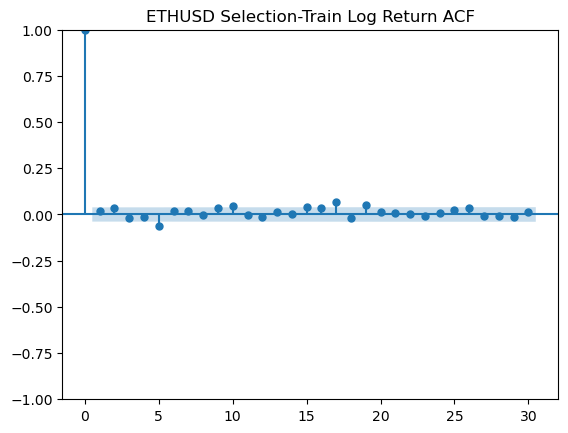

In [7]:
plot_acf(
    train_log_return,
    lags=30
)

plt.title(
    "ETHUSD Selection-Train Log Return ACF"
)

plt.show()

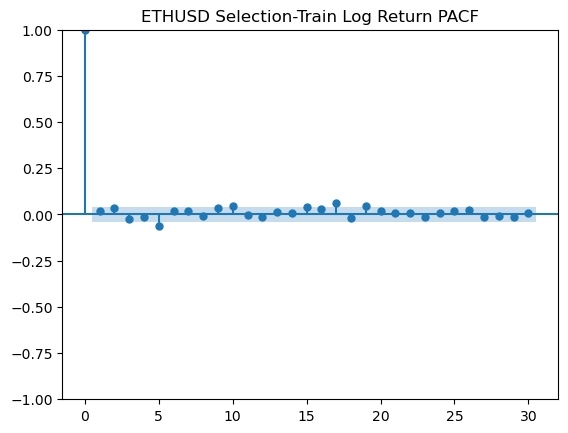

In [8]:
plot_pacf(
    train_log_return,
    lags=30,
    method="ywm"
)

plt.title(
    "ETHUSD Selection-Train Log Return PACF"
)

plt.show()

In [ ]:
### ETHUSD ACF and PACF Analysis

The Selection-Train ACF and PACF show generally weak autocorrelation in ETHUSD log returns.

However, two features remain visible:

- a small negative relationship around Lag 5;
- a positive spike around Lag 16–17.

Importantly, these patterns remain present even after restricting the analysis to the earlier Selection-Train period ending in September 2022.

This suggests that the Lag-5 and Lag-17 relationships are not solely driven by the later validation period. Nevertheless, the correlations remain relatively small and do not form a clear conventional cutoff or decay pattern.

Therefore, both low-order ARIMA models and selected higher-order specifications incorporating Lag 5 and Lag 17 will be evaluated using AIC/BIC and subsequent out-of-sample validation.

In [9]:
candidate_orders = [
    # Basic low-order models
    (0, 1, 0),
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1),

    # Slightly richer low-order models
    (2, 1, 0),
    (0, 1, 2),
    (2, 1, 1),
    (1, 1, 2),

    # Lag-5 candidates
    (5, 1, 0),
    (0, 1, 5),

    # Lag-17 candidates
    (17, 1, 0),
    (0, 1, 17)
]

In [10]:
selection_results = []

for order in candidate_orders:

    try:

        model = ARIMA(
            train_log_price.to_numpy(dtype=float),
            order=order,
            trend="n"
        )

        with warnings.catch_warnings():
            warnings.simplefilter(
                "ignore",
                ConvergenceWarning
            )

            fitted_model = model.fit()

        converged = (
            fitted_model
            .mle_retvals
            .get("converged", True)
        )

        selection_results.append({
            "Order": order,
            "AIC": fitted_model.aic,
            "BIC": fitted_model.bic,
            "Converged": converged
        })

    except Exception as e:

        selection_results.append({
            "Order": order,
            "AIC": np.nan,
            "BIC": np.nan,
            "Converged": False
        })

        print(
            f"ARIMA{order} failed:",
            e
        )

In [12]:
selection_comparison_df = (
    pd.DataFrame(selection_results)
    .sort_values("AIC")
    .reset_index(drop=True)
)

selection_comparison_df

,Order,AIC,BIC,Converged
0,"(17, 1, 0)",-6810.711637,-6705.297885,True
1,"(0, 1, 17)",-6808.199765,-6702.786013,True
2,"(5, 1, 0)",-6794.639132,-6759.501214,True
3,"(0, 1, 5)",-6794.029959,-6758.892042,True
4,"(2, 1, 1)",-6787.677068,-6764.251790,True
5,"(0, 1, 2)",-6787.528024,-6769.959066,True
6,"(2, 1, 0)",-6787.181265,-6769.612307,True
7,"(0, 1, 0)",-6784.964055,-6779.107736,False
8,"(1, 1, 0)",-6784.520252,-6772.807613,True
9,"(0, 1, 1)",-6784.386249,-6772.673610,True


In [13]:
def create_arima_target(
    full_df,
    test_df,
    horizon
):
    horizon_map = {
        "30D": pd.Timedelta(days=30),
        "3M": pd.DateOffset(months=3),
        "6M": pd.DateOffset(months=6)
    }

    if horizon not in horizon_map:
        raise ValueError(
            f"Unsupported horizon: {horizon}"
        )

    target_df = test_df[
        ["Date", "Close", "Log_Price"]
    ].copy()

    target_df["Target_Date"] = (
        target_df["Date"]
        + horizon_map[horizon]
    )

    future_prices = full_df[
        ["Date", "Close", "Log_Price"]
    ].copy()

    future_prices = future_prices.rename(
        columns={
            "Date": "Future_Date",
            "Close": "Future_Close",
            "Log_Price": "Future_Log_Price"
        }
    )

    target_df = pd.merge_asof(
        target_df.sort_values("Target_Date"),
        future_prices.sort_values("Future_Date"),
        left_on="Target_Date",
        right_on="Future_Date",
        direction="forward"
    )

    target_df = target_df.dropna(
        subset=["Future_Date", "Future_Close"]
    ).copy()

    return target_df

In [14]:
def run_arima_walk_forward(
    full_df,
    test_target_df,
    order,
    refit_every=5
):
    rolling_results = []

    fitted_model = None
    last_model_date = None

    non_converged = 0
    failed_windows = 0
    skipped_windows = 0
    refit_count = 0

    for i in range(len(test_target_df)):

        row = test_target_df.iloc[i]

        current_date = row["Date"]
        current_close = row["Close"]
        future_date = row["Future_Date"]
        future_close = row["Future_Close"]

        forecast_dates = full_df[
            (full_df["Date"] > current_date)
            &
            (full_df["Date"] <= future_date)
        ]

        steps = len(forecast_dates)

        if steps == 0:
            skipped_windows += 1
            continue

        try:

            if (
                fitted_model is None
                or i % refit_every == 0
            ):

                history = full_df[
                    full_df["Date"] <= current_date
                ]["Log_Price"].dropna()

                history_values = (
                    history.to_numpy(dtype=float)
                )

                model = ARIMA(
                    history_values,
                    order=order,
                    trend="n"
                )

                with warnings.catch_warnings():

                    warnings.simplefilter(
                        "ignore",
                        ConvergenceWarning
                    )

                    fitted_model = model.fit()

                refit_count += 1
                last_model_date = current_date

                converged = (
                    fitted_model
                    .mle_retvals
                    .get("converged", True)
                )

                if not converged:
                    non_converged += 1

            else:

                new_data = full_df[
                    (full_df["Date"] > last_model_date)
                    &
                    (full_df["Date"] <= current_date)
                ]["Log_Price"].dropna()

                if len(new_data) > 0:

                    new_values = (
                        new_data.to_numpy(dtype=float)
                    )

                    fitted_model = (
                        fitted_model.append(
                            new_values,
                            refit=False
                        )
                    )

                last_model_date = current_date

            forecast_log = (
                fitted_model.forecast(
                    steps=steps
                )
            )

            predicted_log_price = (
                np.asarray(forecast_log)[-1]
            )

            predicted_future_price = np.exp(
                predicted_log_price
            )

            predicted_return = (
                predicted_future_price
                / current_close
                - 1
            )

            actual_return = (
                future_close
                / current_close
                - 1
            )

            rolling_results.append({
                "Date": current_date,
                "Current_Close": current_close,
                "Future_Date": future_date,
                "Forecast_Steps": steps,
                "Actual_Future_Price": future_close,
                "Predicted_Future_Price": predicted_future_price,
                "Actual_Return": actual_return,
                "Predicted_Return": predicted_return
            })

        except Exception as e:

            failed_windows += 1

            print(
                f"Failed on {current_date}: {e}"
            )

    prediction_df = pd.DataFrame(
        rolling_results
    )

    diagnostics = {
        "Forecasts": len(prediction_df),
        "Refit_Count": refit_count,
        "Non_Converged": non_converged,
        "Skipped_Windows": skipped_windows,
        "Failed_Windows": failed_windows
    }

    return prediction_df, diagnostics

In [15]:
def calculate_arima_metrics(
    prediction_df,
    asset_name,
    horizon,
    model_name="ARIMA"
):
    y_true = prediction_df["Actual_Return"]
    y_pred = prediction_df["Predicted_Return"]

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    directional_accuracy = np.mean(
        np.sign(y_true.values)
        ==
        np.sign(y_pred.values)
    )

    baseline_pred = np.zeros(
        len(y_true)
    )

    baseline_mae = mean_absolute_error(
        y_true,
        baseline_pred
    )

    baseline_rmse = np.sqrt(
        mean_squared_error(
            y_true,
            baseline_pred
        )
    )

    mae_improvement = (
        baseline_mae - mae
    )

    rmse_improvement = (
        baseline_rmse - rmse
    )

    metrics_raw = {
        "Asset": asset_name,
        "Model": model_name,
        "Horizon": horizon,
        "Samples": int(len(prediction_df)),
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "Directional_Accuracy": float(
            directional_accuracy
        ),
        "Baseline_MAE": float(
            baseline_mae
        ),
        "Baseline_RMSE": float(
            baseline_rmse
        ),
        "MAE_Improvement_vs_Baseline": float(
            mae_improvement
        ),
        "RMSE_Improvement_vs_Baseline": float(
            rmse_improvement
        )
    }

    metrics_display = {
        "Asset": asset_name,
        "Model": model_name,
        "Horizon": horizon,
        "Samples": int(len(prediction_df)),
        "MAE_%": round(mae * 100, 2),
        "RMSE_%": round(rmse * 100, 2),
        "R2": round(r2, 3),
        "Directional_Accuracy_%": round(
            directional_accuracy * 100,
            2
        ),
        "Baseline_MAE_%": round(
            baseline_mae * 100,
            2
        ),
        "Baseline_RMSE_%": round(
            baseline_rmse * 100,
            2
        ),
        "MAE_Improvement_pp": round(
            mae_improvement * 100,
            2
        ),
        "RMSE_Improvement_pp": round(
            rmse_improvement * 100,
            2
        )
    }

    return metrics_raw, metrics_display

In [16]:
validation_history = (
    eth_arima.iloc[:validation_end]
    .copy()
)

eth_validation_30d_target = (
    create_arima_target(
        full_df=validation_history,
        test_df=validation_df,
        horizon="30D"
    )
)

print(
    "Valid ETHUSD Validation 30D samples:",
    len(eth_validation_30d_target)
)

Valid ETHUSD Validation 30D samples: 616


In [17]:
eth_validation_orders = [
    (1, 1, 0),     # BIC-preferred simple model

    (5, 1, 0),     # Lag-5 AR
    (0, 1, 5),     # Lag-5 MA

    (17, 1, 0),    # AIC-preferred Lag-17 AR
    (0, 1, 17)     # Lag-17 MA
]

In [18]:
eth_validation_metrics = []
eth_validation_predictions = {}
eth_validation_diagnostics = {}

for order in eth_validation_orders:

    print(
        f"\nRunning ETHUSD Validation ARIMA{order} 30D..."
    )

    prediction_df, diagnostics = (
        run_arima_walk_forward(
            full_df=validation_history,
            test_target_df=eth_validation_30d_target,
            order=order,
            refit_every=5
        )
    )

    metrics_raw, metrics_display = (
        calculate_arima_metrics(
            prediction_df=prediction_df,
            asset_name="ETHUSD",
            horizon="30D",
            model_name=f"ARIMA{order}"
        )
    )

    metrics_display["Order"] = str(order)

    eth_validation_metrics.append(
        metrics_display
    )

    eth_validation_predictions[
        str(order)
    ] = prediction_df

    eth_validation_diagnostics[
        str(order)
    ] = diagnostics

    print(
        f"Completed ARIMA{order}:",
        len(prediction_df),
        "forecasts"
    )

    print(
        "Diagnostics:",
        diagnostics
    )


Running ETHUSD Validation ARIMA(1, 1, 0) 30D...
Completed ARIMA(1, 1, 0): 616 forecasts
Diagnostics: {'Forecasts': 616, 'Refit_Count': 124, 'Non_Converged': 5, 'Skipped_Windows': 0, 'Failed_Windows': 0}

Running ETHUSD Validation ARIMA(5, 1, 0) 30D...
Completed ARIMA(5, 1, 0): 616 forecasts
Diagnostics: {'Forecasts': 616, 'Refit_Count': 124, 'Non_Converged': 3, 'Skipped_Windows': 0, 'Failed_Windows': 0}

Running ETHUSD Validation ARIMA(0, 1, 5) 30D...
Completed ARIMA(0, 1, 5): 616 forecasts
Diagnostics: {'Forecasts': 616, 'Refit_Count': 124, 'Non_Converged': 5, 'Skipped_Windows': 0, 'Failed_Windows': 0}

Running ETHUSD Validation ARIMA(17, 1, 0) 30D...
Completed ARIMA(17, 1, 0): 616 forecasts
Diagnostics: {'Forecasts': 616, 'Refit_Count': 124, 'Non_Converged': 0, 'Skipped_Windows': 0, 'Failed_Windows': 0}

Running ETHUSD Validation ARIMA(0, 1, 17) 30D...
Completed ARIMA(0, 1, 17): 616 forecasts
Diagnostics: {'Forecasts': 616, 'Refit_Count': 124, 'Non_Converged': 3, 'Skipped_Windows': 

In [19]:
eth_validation_comparison = (
    pd.DataFrame(
        eth_validation_metrics
    )
    .sort_values("RMSE_%")
    .reset_index(drop=True)
)

eth_validation_comparison

,Asset,Model,Horizon,Samples,MAE_%,RMSE_%,R2,Directional_Accuracy_%,Baseline_MAE_%,Baseline_RMSE_%,MAE_Improvement_pp,RMSE_Improvement_pp,Order
0,ETHUSD,"ARIMA(1, 1, 0)",30D,616,12.03,16.59,-0.119,50.00,12.03,16.59,-0.00,-0.00,"(1, 1, 0)"
1,ETHUSD,"ARIMA(5, 1, 0)",30D,616,12.07,16.60,-0.120,47.56,12.03,16.59,-0.04,-0.01,"(5, 1, 0)"
2,ETHUSD,"ARIMA(0, 1, 5)",30D,616,12.06,16.60,-0.120,47.89,12.03,16.59,-0.03,-0.01,"(0, 1, 5)"
3,ETHUSD,"ARIMA(0, 1, 17)",30D,616,12.16,16.90,-0.162,54.22,12.03,16.59,-0.13,-0.31,"(0, 1, 17)"
4,ETHUSD,"ARIMA(17, 1, 0)",30D,616,12.19,16.97,-0.172,54.22,12.03,16.59,-0.16,-0.38,"(17, 1, 0)"


In [ ]:
### ETHUSD ARIMA Model Selection

The model-selection process produced an important contrast between in-sample fit and out-of-sample forecasting performance.

The ACF and PACF identified weak but persistent autocorrelation around Lag 5 and Lag 17. Consistent with this observation, AIC strongly favored the higher-order ARIMA(17,1,0) specification.

However, BIC favored substantially simpler models because of the large complexity penalty associated with the additional parameters.

The 30-day validation results provided the decisive evidence. ARIMA(1,1,0) achieved the lowest MAE and RMSE among the candidate specifications, while both Lag-17 models produced larger forecast errors despite somewhat higher directional accuracy.

This indicates that the additional Lag-17 structure improves in-sample fit but does not generalize reliably to out-of-sample return-magnitude forecasting.

Therefore, the final ETHUSD specification is:

ARIMA(1,1,0)

The model is selected based primarily on validation MAE and RMSE, supported by its greater parsimony. However, its validation performance remained approximately equal to the zero-return baseline, indicating limited predictive edge.

In [20]:
ETH_ORDER = (1, 1, 0)

print(
    "Selected ETHUSD ARIMA order:",
    ETH_ORDER
)

Selected ETHUSD ARIMA order: (1, 1, 0)


In [21]:
eth_final_horizons = [
    "30D",
    "3M",
    "6M"
]

eth_final_predictions = {}

eth_final_metrics_raw = []
eth_final_metrics_display = []

eth_final_diagnostics = {}

In [22]:
for horizon in eth_final_horizons:

    print(
        f"\nRunning ETHUSD ARIMA{ETH_ORDER} {horizon}..."
    )

    # Construct calendar-aligned target
    target_df = create_arima_target(
        full_df=eth_arima,
        test_df=final_test_df,
        horizon=horizon
    )

    # Walk-forward forecasting
    prediction_df, diagnostics = (
        run_arima_walk_forward(
            full_df=eth_arima,
            test_target_df=target_df,
            order=ETH_ORDER,
            refit_every=5
        )
    )

    # Metrics
    metrics_raw, metrics_display = (
        calculate_arima_metrics(
            prediction_df=prediction_df,
            asset_name="ETHUSD",
            horizon=horizon,
            model_name="ARIMA"
        )
    )

    eth_final_predictions[
        horizon
    ] = prediction_df

    eth_final_metrics_raw.append(
        metrics_raw
    )

    eth_final_metrics_display.append(
        metrics_display
    )

    eth_final_diagnostics[
        horizon
    ] = diagnostics

    print(
        f"{horizon} completed:",
        len(prediction_df),
        "forecasts"
    )

    print(
        "Diagnostics:",
        diagnostics
    )


Running ETHUSD ARIMA(1, 1, 0) 30D...
30D completed: 778 forecasts
Diagnostics: {'Forecasts': 778, 'Refit_Count': 156, 'Non_Converged': 17, 'Skipped_Windows': 0, 'Failed_Windows': 0}

Running ETHUSD ARIMA(1, 1, 0) 3M...
3M completed: 716 forecasts
Diagnostics: {'Forecasts': 716, 'Refit_Count': 144, 'Non_Converged': 16, 'Skipped_Windows': 0, 'Failed_Windows': 0}

Running ETHUSD ARIMA(1, 1, 0) 6M...
6M completed: 627 forecasts
Diagnostics: {'Forecasts': 627, 'Refit_Count': 126, 'Non_Converged': 11, 'Skipped_Windows': 0, 'Failed_Windows': 0}


In [23]:
eth_final_metrics_raw_df = pd.DataFrame(
    eth_final_metrics_raw
)

eth_final_metrics_display_df = pd.DataFrame(
    eth_final_metrics_display
)

eth_final_metrics_display_df

,Asset,Model,Horizon,Samples,MAE_%,RMSE_%,R2,Directional_Accuracy_%,Baseline_MAE_%,Baseline_RMSE_%,MAE_Improvement_pp,RMSE_Improvement_pp
0,ETHUSD,ARIMA,30D,778,16.37,21.60,0.000,50.26,16.37,21.61,0.0,0.0
1,ETHUSD,ARIMA,3M,716,34.60,41.94,-0.001,49.72,34.60,41.95,-0.0,0.0
2,ETHUSD,ARIMA,6M,627,39.22,53.32,-0.000,48.17,39.22,53.32,-0.0,-0.0


In [24]:
pd.DataFrame(
    eth_final_diagnostics
).T

,Forecasts,Refit_Count,Non_Converged,Skipped_Windows,Failed_Windows
30D,778,156,17,0,0
3M,716,144,16,0,0
6M,627,126,11,0,0


In [25]:
ETH_ARIMA_FORECASTS = (
    ARIMA_FORECASTS / "ETHUSD"
)

ETH_ARIMA_METRICS = (
    ARIMA_METRICS / "ETHUSD"
)

ETH_ARIMA_FORECASTS.mkdir(
    parents=True,
    exist_ok=True
)

ETH_ARIMA_METRICS.mkdir(
    parents=True,
    exist_ok=True
)


In [26]:
for horizon, prediction_df in eth_final_predictions.items():

    output_path = (
        ETH_ARIMA_FORECASTS
        / f"ETHUSD_ARIMA_{horizon}_predictions.csv"
    )

    prediction_df.to_csv(
        output_path,
        index=False
    )

    print(
        f"Saved: {output_path}"
    )

Saved: D:\multi-horizon-asset-price-forecasting\results\arima_forecasts\ETHUSD\ETHUSD_ARIMA_30D_predictions.csv
Saved: D:\multi-horizon-asset-price-forecasting\results\arima_forecasts\ETHUSD\ETHUSD_ARIMA_3M_predictions.csv
Saved: D:\multi-horizon-asset-price-forecasting\results\arima_forecasts\ETHUSD\ETHUSD_ARIMA_6M_predictions.csv


In [27]:
raw_metrics_path = (
    ETH_ARIMA_METRICS
    / "ETHUSD_ARIMA_metrics_raw.csv"
)

eth_final_metrics_raw_df.to_csv(
    raw_metrics_path,
    index=False
)

print(
    f"Saved: {raw_metrics_path}"
)

Saved: D:\multi-horizon-asset-price-forecasting\results\arima_metrics\ETHUSD\ETHUSD_ARIMA_metrics_raw.csv


In [28]:
display_metrics_path = (
    ETH_ARIMA_METRICS
    / "ETHUSD_ARIMA_metrics_display.csv"
)

eth_final_metrics_display_df.to_csv(
    display_metrics_path,
    index=False
)

print(
    f"Saved: {display_metrics_path}"
)

Saved: D:\multi-horizon-asset-price-forecasting\results\arima_metrics\ETHUSD\ETHUSD_ARIMA_metrics_display.csv
